# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

In [2]:
data_raw = pd.read_csv('data/cash_app_report_1782441067984.csv')
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-06-26 00:00:00 EDT,NaN,Stock Dividends,USD,$0.18,$0.00,$0.18,VNQ,NaN,NaN,COMPLETE,$0.18 Dividend from Vanguard Real Estate ETF,NaN,Cash Balance
1,2026-06-26 00:00:00 EDT,NaN,Stock Dividends,USD,$0.17,$0.00,$0.17,DKS,NaN,NaN,COMPLETE,$0.17 Dividend from Dick's Sporting Goods,NaN,Cash Balance
2,2026-06-26 00:00:00 EDT,NaN,Stock Dividends,USD,$0.04,$0.00,$0.04,VCR,NaN,NaN,COMPLETE,$0.04 Dividend from Vanguard Consumer Discreti...,NaN,Cash Balance
3,2026-06-26 00:00:00 EDT,NaN,Stock Dividends,USD,$0.30,$0.00,$0.30,VFH,NaN,NaN,COMPLETE,$0.30 Dividend from Vanguard Financials ETF,NaN,Cash Balance
4,2026-06-26 00:00:00 EDT,NaN,Stock Dividends,USD,$0.11,$0.00,$0.11,VHT,NaN,NaN,COMPLETE,$0.11 Dividend from Vanguard Health Care ETF,NaN,Cash Balance
5,2026-06-26 00:00:00 EDT,NaN,Stock Dividends,USD,$0.11,$0.00,$0.11,VDC,NaN,NaN,COMPLETE,$0.11 Dividend from Vanguard Consumer Staples ...,NaN,Cash Balance
6,2026-06-26 00:00:00 EDT,NaN,Stock Dividends,USD,$0.20,$0.00,$0.20,VDE,NaN,NaN,COMPLETE,$0.20 Dividend from Energy ETF Vanguard,NaN,Cash Balance
7,2026-06-26 00:00:00 EDT,NaN,Stock Dividends,USD,$0.01,$0.00,$0.01,NVDA,NaN,NaN,COMPLETE,$0.01 Dividend from NVIDIA,NaN,Cash Balance
8,2026-06-25 00:00:00 EDT,NaN,Stock Dividends,USD,$0.06,$0.00,$0.06,PYPL,NaN,NaN,COMPLETE,$0.06 Dividend from PayPal,NaN,Cash Balance
9,2026-06-25 00:00:00 EDT,NaN,Stock Dividends,USD,$0.11,$0.00,$0.11,FIS,NaN,NaN,COMPLETE,$0.11 Dividend from Fidelity National Information,NaN,Cash Balance


In [3]:
data_raw[data_raw['Transaction Type'].isna()]

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
22,2026-06-22 13:17:10 EDT,NaN,NaN,USD,$8.00,$0.00,$8.00,HOOD,$106.87,0.07485,COMPLETE,$8 Sale of Robinhood Markets,NaN,Cash Balance
23,2026-06-22 13:16:52 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HIMS,$33.58,0.29775,COMPLETE,$10 Sale of Hims & Hers Health,NaN,Cash Balance
26,2026-06-22 09:33:17 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,WFC,$82.92,0.12059,COMPLETE,$10 Sale of Wells Fargo,NaN,Cash Balance
27,2026-06-22 09:33:13 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.28,0.13462,COMPLETE,$10 Sale of Block,NaN,Cash Balance
31,2026-06-22 09:30:48 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,MRVL,$313.48,0.03189,COMPLETE,$10 Sale of Marvell Technology,NaN,Cash Balance
32,2026-06-22 09:30:44 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HOOD,$108.10,0.09250,COMPLETE,$10 Sale of Robinhood Markets,NaN,Cash Balance
33,2026-06-22 09:30:40 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HIMS,$34.63,0.28876,COMPLETE,$10 Sale of Hims & Hers Health,NaN,Cash Balance
36,2026-06-22 09:30:20 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,DKS,$237.13,0.04217,COMPLETE,$10 Sale of Dick's Sporting Goods,NaN,Cash Balance
37,2026-06-22 09:30:19 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,DAL,$84.50,0.11834,COMPLETE,$10 Sale of Delta Air Lines,NaN,Cash Balance
41,2026-06-22 09:30:15 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,JPM,$329.00,0.03039,COMPLETE,$10 Sale of JPMorgan Chase,NaN,Cash Balance


In [4]:
data_raw['Asset Amount'].fillna(None).astype(float)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
594   NaN
595   NaN
596   NaN
597   NaN
598   NaN
Name: Asset Amount, Length: 599, dtype: float64

In [5]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE).sort_values('date')

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
522,2026-05-30 03:40:07+00:00,-25.0,-24.5,74060.49,0.000331,-0.5,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00033081,NaN
448,2026-06-01 13:30:50+00:00,-10.0,-10.0,183.25,0.054570,0.0,TM,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Toyota Motor,NaN
386,2026-06-03 13:30:07+00:00,-10.0,-10.0,125.39,0.079750,0.0,VFH,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard Financials ETF,NaN
380,2026-06-03 13:30:10+00:00,-10.0,-10.0,183.16,0.054590,0.0,ACN,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Accenture,NaN
344,2026-06-03 13:33:56+00:00,-1.0,-1.0,72.82,0.013730,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Block,NaN
302,2026-06-03 15:50:37+00:00,100.0,100.0,NaN,0.000000,0.0,NaN,Deposits,USD,NaN,Visa debit 3333,COMPLETE,Add Cash,NaN
284,2026-06-03 18:45:50+00:00,-10.0,-10.0,31.85,0.314000,0.0,PZZA,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Papa John's,NaN
241,2026-06-03 19:46:16+00:00,-10.0,-10.0,275.16,0.036340,0.0,VHT,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard Health Care ETF,NaN
185,2026-06-08 16:37:34+00:00,-10.0,-10.0,312.95,0.031950,0.0,AAPL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Apple,NaN
121,2026-06-16 13:30:13+00:00,-10.0,-10.0,165.51,0.060410,0.0,CRUS,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Cirrus Logic,NaN


In [6]:
p2p_data = (data[data['trans_type'] == 'P2P']
            [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
            .assign(date=lambda x: x['date'].dt.date)
            )
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
592,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
593,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
594,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
596,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
597,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
598,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


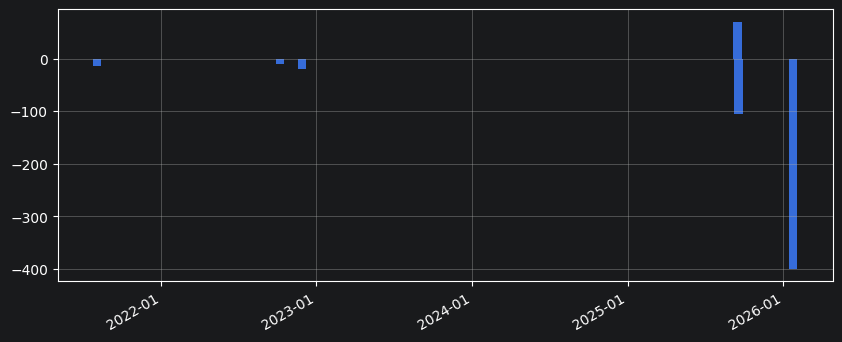

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [8]:
data.describe()

,net_amount,amount,asset_price,asset_amount,fee
count,599.000000,599.000000,490.000000,599.000000,596.000000
mean,0.108247,0.118164,4072.758204,0.133717,-0.009966
std,39.468523,39.466165,16159.608872,0.281228,0.055179
min,-400.000000,-400.000000,4.570000,0.000000,-0.500000
25%,-10.000000,-10.000000,56.212500,0.009530,0.000000
50%,-10.000000,-10.000000,131.800000,0.045710,0.000000
75%,-5.000000,-4.900000,300.640000,0.127090,0.000000
max,200.000000,200.000000,80346.140000,3.185880,0.000000


In [9]:
data.nunique().sort_values(ascending=False)

asset_price     484
asset_amount    482
date            468
notes           354
asset_type      166
amount           52
net_amount       51
trans_type       10
trans_id          7
fee               6
account           5
name_trans        5
status            2
currency          1
dtype: int64

In [10]:
data['asset_type'].value_counts()

asset_type
BTC     27
XYZ     12
JPM     12
META    10
PZZA    10
        ..
HPQ      1
ADBE     1
JEPI     1
CBRS     1
AVGO     1
Name: count, Length: 166, dtype: int64

Text(0, 0.5, 'Count')

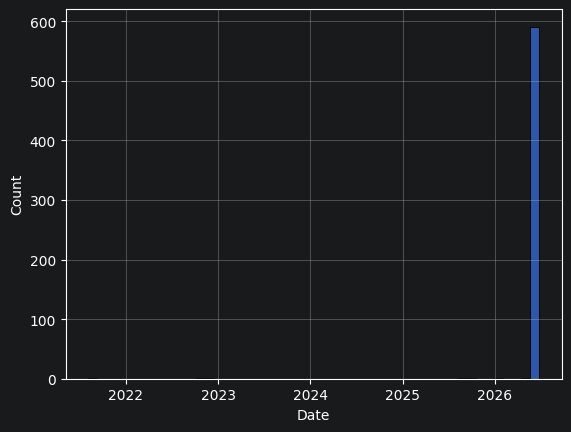

In [11]:
sns.histplot(data=data, x='date', bins=50)

plt.grid()
plt.xlabel('Date')
plt.ylabel('Count')

In [12]:
data['date'].dt.date.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame().T

,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
date,2026-01-23,2026-05-27,2026-05-29,2026-06-01,2026-06-03,2026-06-16,2026-06-18,2026-06-22,2026-06-26


In [13]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,27,-172.26,"(-24.5, -9.8, -4.9, -0.98, 5.0, 10.0, 20.0)",7
XYZ,12,-161.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
JPM,12,-70.00,"(-25.0, -10.0, -5.0, 10.0, 20.0)",5
ORCL,10,-85.00,"(-10.0, -5.0)",2
WFC,10,-71.00,"(-25.0, -10.0, -5.0, -1.0, 10.0)",5
META,10,-70.95,"(-10.0, -5.0, -1.0, 0.05)",4
PZZA,10,-85.00,"(-25.0, -10.0, -5.0, 10.0)",4
AMZN,9,-151.00,"(-50.0, -25.0, -10.0, -1.0)",4
V,9,-101.00,"(-25.0, -20.0, -10.0, -5.0, -1.0)",5


In [14]:
data['currency'].value_counts()

currency
USD    599
Name: count, dtype: int64

In [15]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    430
Deposits                      63
Stock Sell                    33
Stock Dividends               24
Bitcoin Buy                   22
Savings Internal Transfer     12
P2P                            6
Bitcoin Sell                   5
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [16]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,22,5,430,24,33,514
BTC,22,5,0,0,0,27
XYZ,0,0,11,0,1,12
JPM,0,0,10,0,2,12
WFC,0,0,9,0,1,10
ORCL,0,0,10,0,0,10
PZZA,0,0,9,0,1,10
META,0,0,9,1,0,10
AMZN,0,0,9,0,0,9


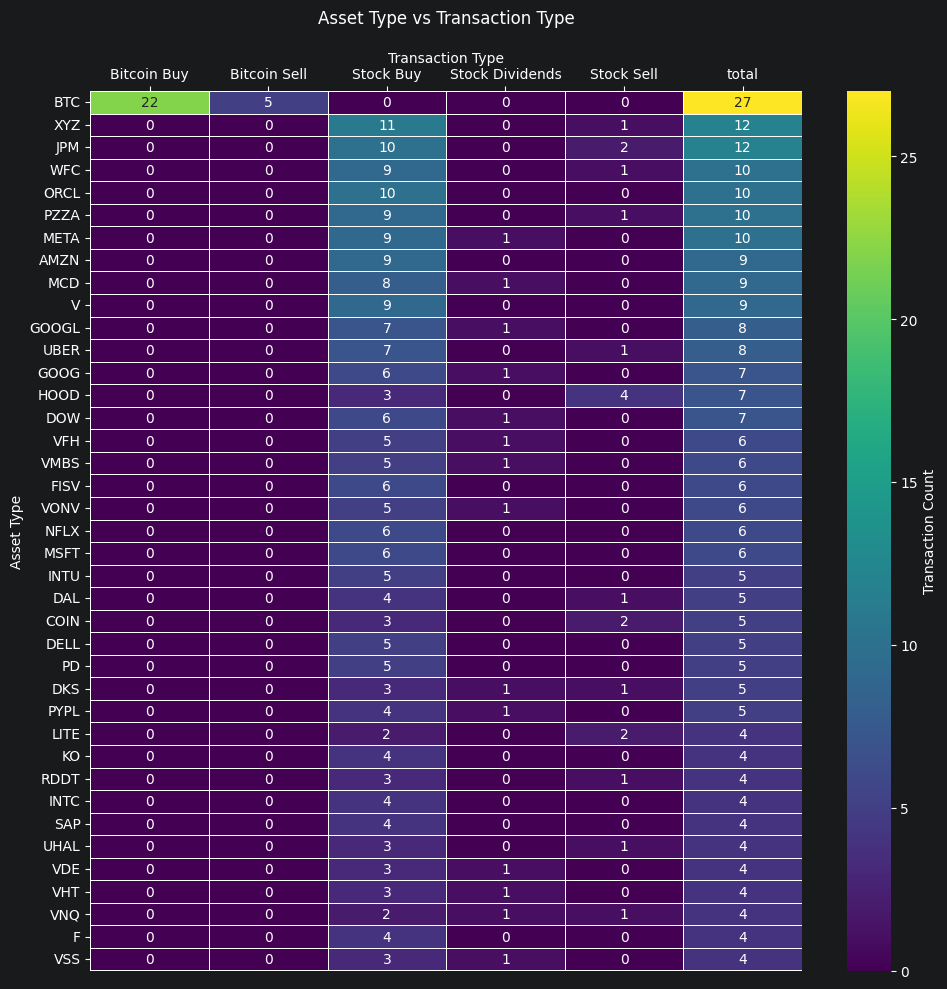

In [17]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [18]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
54,2026-06-20 20:54:15+00:00,9.8,10.00,63371.65,0.000158,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015780,NaN
56,2026-06-20 11:51:40+00:00,-5.0,-4.90,64191.63,0.000076,-0.10,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00007633,NaN
65,2026-06-18 17:13:37+00:00,19.6,20.00,61888.37,0.000323,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032316,NaN
147,2026-06-16 12:39:28+00:00,4.9,5.00,66069.72,0.000076,-0.10,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00007568,NaN
148,2026-06-16 12:03:53+00:00,4.9,5.00,65883.50,0.000076,-0.10,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00007589,NaN
151,2026-06-16 01:27:11+00:00,-5.0,-4.90,66797.17,0.000073,-0.10,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00007336,NaN
187,2026-06-08 16:36:43+00:00,19.6,20.00,63160.58,0.000317,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00031665,NaN
267,2026-06-03 19:29:17+00:00,-10.0,-9.80,66010.01,0.000148,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014846,NaN
294,2026-06-03 16:16:50+00:00,-10.0,-9.80,66582.56,0.000147,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014719,NaN
318,2026-06-03 15:14:44+00:00,-1.0,-0.98,66904.02,0.000015,-0.02,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00001465,NaN


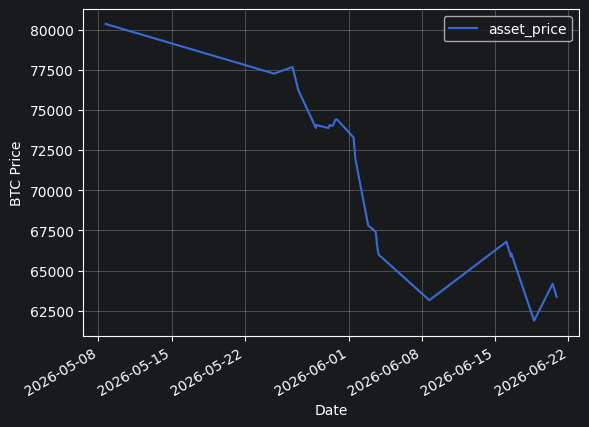

In [19]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [20]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     22
Bitcoin Sell     5
Name: count, dtype: int64

In [21]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-237.0
Bitcoin Sell,58.8


In [22]:
data_btc['net_amount'].sum()

np.float64(-178.2)

In [23]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003176
Bitcoin Sell    0.000949
Name: asset_amount, dtype: float64

In [24]:
data_btc['asset_amount'].sum()

np.float64(0.00412535)

In [25]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00222699)

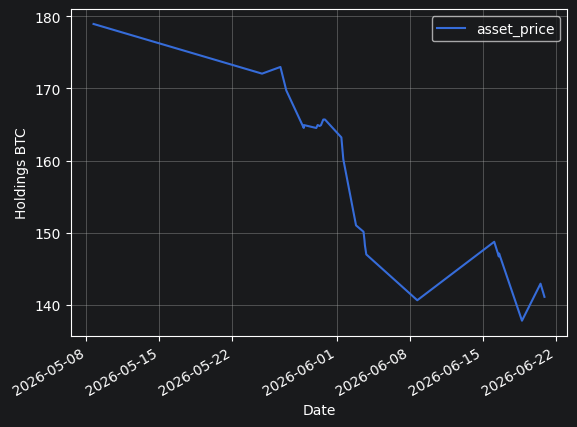

In [26]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [27]:
data_btc['asset_price'] * data_btc['asset_amount']

54     10.000046
56      4.899747
65     19.999846
147     5.000156
148     4.999899
151     4.900240
187    19.999798
267     9.799846
294     9.800287
318     0.980144
415     9.800221
426     0.979969
443     9.799652
501     4.900136
503     9.799865
506     4.900112
507     9.799903
511     9.799965
515    24.500200
522    24.499951
526    24.500084
545     9.799731
549     9.800031
572    24.499991
589     9.799898
590     4.900356
591     9.799819
dtype: float64

In [28]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
27,2026-06-22 13:33:13+00:00,10.0,10.0,74.28,0.13462,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,COMPLETE,$10 Sale of Block,NaN
109,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
154,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
202,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
278,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
290,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
303,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
341,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
344,2026-06-03 13:33:56+00:00,-1.0,-1.0,72.82,0.01373,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Block,NaN
447,2026-06-01 13:30:51+00:00,-25.0,-25.0,77.50,0.32258,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$25 Purchase of Block,NaN


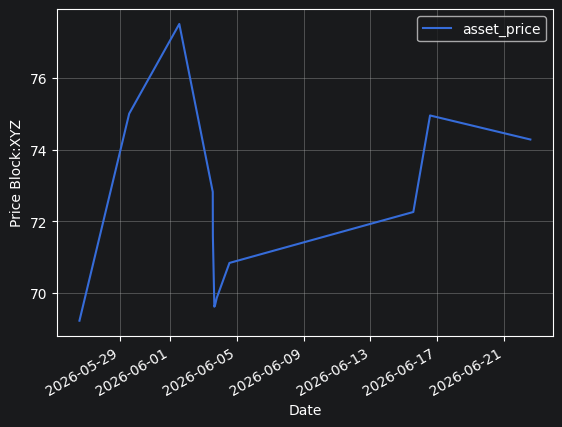

In [29]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [30]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     27
XYZ     12
JPM     12
ORCL    10
WFC     10
        ..
NET      1
MU       1
MSGS     1
CG       1
ZG       1
Name: amount, Length: 166, dtype: int64

In [31]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,6.28,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [32]:
data['asset_amount'].describe()

count    599.000000
mean       0.133717
std        0.281228
min        0.000000
25%        0.009530
50%        0.045710
75%        0.127090
max        3.185880
Name: asset_amount, dtype: float64

In [33]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
)
asset_holding_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 17:41:00+00:00,20.147721,9.999493,9.010079,9.9981,19.320923,9.999577,19.549552,0.000000,14.039852,0.000000,...,0.000000,51.890247,9.686363,29.991989,0.0,120.086268,19.945984,9.953370,0.000000,0.000000
2026-06-22 13:31:02+00:00,38.690715,9.999493,16.180396,9.9981,29.320654,9.999577,19.549552,21.050186,9.042617,30.069556,...,0.000000,85.406771,23.724046,29.991989,0.0,174.501547,40.190894,19.954137,9.999727,9.999925
2026-06-22 13:33:13+00:00,38.690715,9.999493,16.180396,9.9981,29.320654,9.999577,19.549552,21.050186,9.042617,30.069556,...,0.000000,85.406771,23.724046,29.991989,0.0,164.501974,40.190894,19.954137,9.999727,9.999925
2026-06-23 17:26:24+00:00,38.690715,9.999493,16.180396,9.9981,29.320654,9.999577,19.549552,21.050186,9.042617,30.069556,...,20.007326,75.407448,23.724046,29.991989,0.0,164.501974,40.190894,19.954137,9.999727,9.999925
2026-06-12 04:00:00+00:00,28.691891,9.999493,9.010079,9.9981,19.320923,9.999577,19.549552,11.051107,14.039852,20.071824,...,0.000000,77.322328,18.724670,29.991989,0.0,154.936279,30.191289,9.953370,9.999727,9.999925
2026-06-03 19:41:22+00:00,20.147721,9.999493,9.010079,9.9981,19.320923,9.999577,19.549552,0.000000,14.039852,20.071824,...,0.000000,63.030258,18.724670,29.991989,0.0,131.892037,30.191289,9.953370,0.000000,0.000000
2026-05-27 13:33:02+00:00,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,21.666750,0.000000,0.000000,0.000000,0.000000
2026-06-03 19:25:59+00:00,20.147721,9.999493,9.010079,9.9981,19.320923,9.999577,19.549552,0.000000,14.039852,0.000000,...,0.000000,51.890247,18.724670,29.991989,0.0,131.892037,19.945984,9.953370,0.000000,0.000000
2026-06-03 18:45:50+00:00,20.147721,9.999493,9.010079,9.9981,19.320923,9.999577,19.549552,0.000000,14.039852,0.000000,...,0.000000,51.890247,18.724670,29.991989,0.0,120.086268,19.945984,9.953370,0.000000,0.000000


In [34]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(3570.7183986)

In [35]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-24 13:30:02+00:00,0.010836,0.0028,0.004531,0.0028,0.008211,0.0028,0.005475,0.005895,0.002532,0.008421,...,0.005603,0.021118,0.006644,0.008399,0.0,0.04607,0.011256,0.005588,0.0028,0.002801
2026-06-24 13:30:06+00:00,0.010836,0.0028,0.004531,0.0028,0.008211,0.0028,0.005475,0.005895,0.002532,0.008421,...,0.005603,0.021118,0.006644,0.008399,0.0,0.04607,0.011256,0.005588,0.0028,0.002801
2026-06-24 13:31:03+00:00,0.010836,0.0028,0.004531,0.0028,0.008211,0.0028,0.005475,0.005895,0.002532,0.008421,...,0.005603,0.021118,0.006644,0.008399,0.0,0.04607,0.011256,0.005588,0.0028,0.002801
2026-06-25 04:00:00+00:00,0.010836,0.0028,0.004531,0.0028,0.008211,0.0028,0.005475,0.005895,0.002532,0.008421,...,0.005603,0.021118,0.006644,0.008399,0.0,0.04607,0.011256,0.005588,0.0028,0.002801
2026-06-26 04:00:00+00:00,0.010836,0.0028,0.004531,0.0028,0.008211,0.0028,0.005475,0.005895,0.002532,0.008421,...,0.005603,0.021118,0.006644,0.008399,0.0,0.04607,0.011256,0.005588,0.0028,0.002801


In [36]:
asset_price_rel.iloc[-1].describe()

count    166.000000
mean       0.006024
std        0.006846
min        0.000000
25%        0.002800
50%        0.004239
75%        0.007002
max        0.046070
Name: 2026-06-26 04:00:00+00:00, dtype: float64

In [37]:
asset_price_rel.iloc[-1].sort_values(ascending=False).head()

asset_type
XYZ     0.046070
AMZN    0.039891
V       0.029174
DELL    0.028787
UBER    0.026932
Name: 2026-06-26 04:00:00+00:00, dtype: float64

In [38]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-24 13:30:02+00:00,0.010836,0.0028,0.004531,0.0028,0.008211,0.0028,0.005475,0.005895,0.002532,0.008421,...,0.005603,0.021118,0.006644,0.008399,0.0,0.04607,0.011256,0.005588,0.0028,0.002801
2026-06-24 13:30:06+00:00,0.010836,0.0028,0.004531,0.0028,0.008211,0.0028,0.005475,0.005895,0.002532,0.008421,...,0.005603,0.021118,0.006644,0.008399,0.0,0.04607,0.011256,0.005588,0.0028,0.002801
2026-06-24 13:31:03+00:00,0.010836,0.0028,0.004531,0.0028,0.008211,0.0028,0.005475,0.005895,0.002532,0.008421,...,0.005603,0.021118,0.006644,0.008399,0.0,0.04607,0.011256,0.005588,0.0028,0.002801
2026-06-25 04:00:00+00:00,0.010836,0.0028,0.004531,0.0028,0.008211,0.0028,0.005475,0.005895,0.002532,0.008421,...,0.005603,0.021118,0.006644,0.008399,0.0,0.04607,0.011256,0.005588,0.0028,0.002801
2026-06-26 04:00:00+00:00,0.010836,0.0028,0.004531,0.0028,0.008211,0.0028,0.005475,0.005895,0.002532,0.008421,...,0.005603,0.021118,0.006644,0.008399,0.0,0.04607,0.011256,0.005588,0.0028,0.002801


In [39]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-27 13:33:02+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 15:07:22+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 13:30:11+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 13:32:08+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:18+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:27:58+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-22 13:30:44+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-04 13:30:12+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-02 16:52:54+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WEN,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-27 13:33:02+00:00,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.0,...,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.0
2026-06-03 15:07:22+00:00,1.021803,1.0,1.000000,1.0,1.000000,1.0,0.954965,1.000000,1.000000,1.0,...,1.0,1.008655,1.000000,0.955619,1.0,1.034089,1.000000,1.000000,1.0,1.0
2026-06-03 13:30:11+00:00,1.021803,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.0,...,1.0,0.989149,1.000000,0.955619,1.0,1.119457,1.000000,1.000000,1.0,1.0
2026-06-16 13:32:08+00:00,1.018386,1.0,0.901125,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.0,...,1.0,1.035138,0.968648,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0
2026-06-01 13:30:18+00:00,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.0,...,1.0,1.000000,1.000000,1.000000,1.0,1.083345,1.000000,1.000000,1.0,1.0
2026-06-03 19:27:58+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.0,...,1.0,1.012014,0.968648,0.976969,1.0,1.009245,1.000000,1.000000,1.0,1.0
2026-06-22 13:30:44+00:00,0.969248,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.404207,1.0,...,1.0,1.082418,0.921293,0.976969,1.0,1.082623,1.005550,0.995338,1.0,1.0
2026-06-04 13:30:12+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.000000,1.0,...,1.0,1.016406,0.968648,0.976969,1.0,1.009245,0.997325,1.000000,1.0,1.0
2026-06-02 16:52:54+00:00,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.000000,1.0,...,1.0,0.989149,1.000000,0.955619,1.0,1.119457,1.000000,1.000000,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

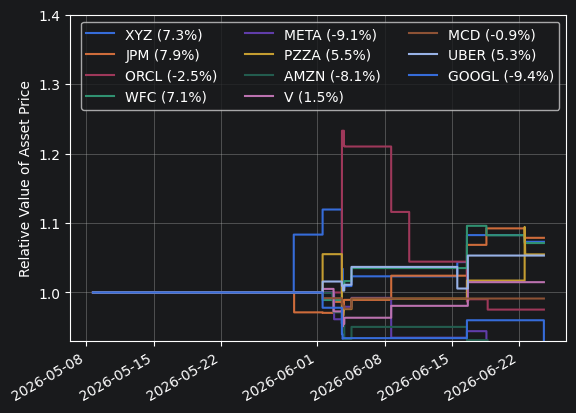

In [41]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.93, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [42]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-06-22 18:57:59+00:00    1.072945
2026-06-23 17:26:24+00:00    1.072945
2026-06-24 13:30:02+00:00    1.072945
2026-06-24 13:30:06+00:00    1.072945
2026-06-24 13:31:03+00:00    1.072945
Name: XYZ, Length: 373, dtype: float64

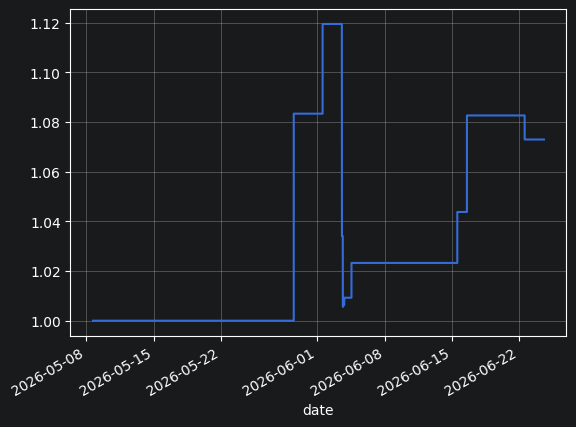

In [43]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [44]:
div_data = (
    data[data['trans_type'] == 'Stock Dividends']
    .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status',
                   'trans_type', 'net_amount'])
    .assign(date=lambda x: x['date'].dt.date)
)
div_data

,date,amount,asset_type,notes
0,2026-06-26,0.18,VNQ,$0.18 Dividend from Vanguard Real Estate ETF
1,2026-06-26,0.17,DKS,$0.17 Dividend from Dick's Sporting Goods
2,2026-06-26,0.04,VCR,$0.04 Dividend from Vanguard Consumer Discreti...
3,2026-06-26,0.30,VFH,$0.30 Dividend from Vanguard Financials ETF
4,2026-06-26,0.11,VHT,$0.11 Dividend from Vanguard Health Care ETF
5,2026-06-26,0.11,VDC,$0.11 Dividend from Vanguard Consumer Staples ...
6,2026-06-26,0.20,VDE,$0.20 Dividend from Energy ETF Vanguard
7,2026-06-26,0.01,NVDA,$0.01 Dividend from NVIDIA
8,2026-06-25,0.06,PYPL,$0.06 Dividend from PayPal
9,2026-06-25,0.11,FIS,$0.11 Dividend from Fidelity National Information


In [45]:
div_data['amount'].sum()

np.float64(2.46)

In [46]:
div_data.sort_values('amount', ascending=False)

,date,amount,asset_type,notes
3,2026-06-26,0.30,VFH,$0.30 Dividend from Vanguard Financials ETF
10,2026-06-25,0.26,BBEU,$0.26 Dividend from JPMorgan BetaBuilders Euro...
6,2026-06-26,0.20,VDE,$0.20 Dividend from Energy ETF Vanguard
149,2026-06-16,0.20,MCD,$0.20 Dividend from McDonald's
0,2026-06-26,0.18,VNQ,$0.18 Dividend from Vanguard Real Estate ETF
1,2026-06-26,0.17,DKS,$0.17 Dividend from Dick's Sporting Goods
20,2026-06-23,0.16,VSS,$0.16 Dividend from Vanguard FTSE All World ex...
19,2026-06-23,0.14,VONV,$0.14 Dividend from Vanguard Russell 1000 Valu...
4,2026-06-26,0.11,VHT,$0.11 Dividend from Vanguard Health Care ETF
5,2026-06-26,0.11,VDC,$0.11 Dividend from Vanguard Consumer Staples ...


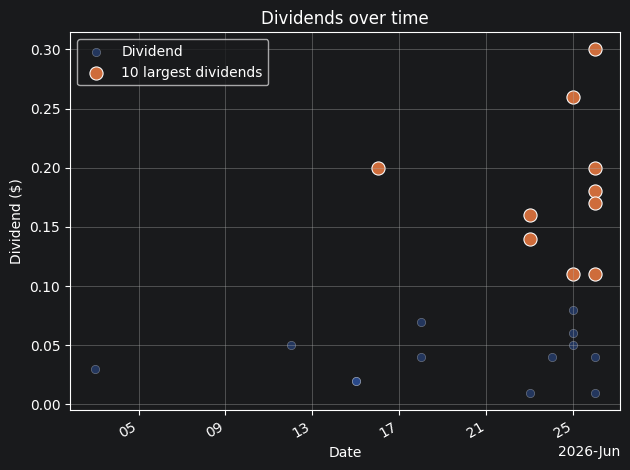

In [63]:
d = div_data.copy()
d["Date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

top10 = d.nlargest(10, "amount")

ax = sns.scatterplot(
    data=d,
    x="date",
    y="amount",
    alpha=0.35,
    label="Dividend",
)

sns.scatterplot(
    data=top10,
    x="date",
    y="amount",
    s=90,
    ax=ax,
    label="10 largest dividends",
)

for _, r in top10.iterrows():
    ax.annotate(
        r["asset_type"],
        (r["date"], r["date"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Dividends over time")
ax.set_xlabel("Date")
ax.set_ylabel("Dividend ($)")

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend()
plt.grid()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

In [48]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
83,2026-06-18 14:09:00+00:00,-5.00,687.48,$5 Purchase of Vanguard S&P 500 ETF,VOO
298,2026-06-03 15:53:29+00:00,-10.00,54.44,$10 Purchase of Vanguard Long-Treasury ETF,VGLT
139,2026-06-16 13:30:03+00:00,-5.00,155.47,$5 Purchase of Energy ETF Vanguard,VDE
71,2026-06-18 17:09:02+00:00,-10.00,126.88,$10 Purchase of Vanguard Russell 1000 Growth ETF,VONG
257,2026-06-03 19:35:58+00:00,-10.00,158.69,$10 Purchase of Vanguard FTSE All World ex US ...,VSS
385,2026-06-03 13:30:09+00:00,-10.00,220.70,$10 Purchase of Vanguard Consumer Staples Inde...,VDC
70,2026-06-18 17:09:36+00:00,10.00,96.10,$10 Sale of Vanguard Real Estate ETF,VNQ
386,2026-06-03 13:30:07+00:00,-10.00,125.39,$10 Purchase of Vanguard Financials ETF,VFH
19,2026-06-23 04:00:00+00:00,0.14,NaN,$0.14 Dividend from Vanguard Russell 1000 Valu...,VONV
123,2026-06-16 13:30:12+00:00,-5.00,107.50,$5 Purchase of Vanguard Russell 1000 Value ETF,VONV


In [49]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VFH     6
VONV    6
VMBS    6
VNQ     4
VHT     4
VDE     4
VSS     4
VCR     3
VDC     3
VONG    3
VOO     3
VBR     2
VTEB    2
VGLT    2
BNDX    2
BIV     1
Name: count, dtype: int64

In [50]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
83,2026-06-18 14:09:00+00:00,-5.00,687.48,VOO,Vanguard S&P 500 ETF
298,2026-06-03 15:53:29+00:00,-10.00,54.44,VGLT,Vanguard Long-Treasury ETF
139,2026-06-16 13:30:03+00:00,-5.00,155.47,VDE,Energy ETF Vanguard
71,2026-06-18 17:09:02+00:00,-10.00,126.88,VONG,Vanguard Russell 1000 Growth ETF
257,2026-06-03 19:35:58+00:00,-10.00,158.69,VSS,Vanguard FTSE All World ex US Small Cap ETF
385,2026-06-03 13:30:09+00:00,-10.00,220.70,VDC,Vanguard Consumer Staples Index Fund ETF
70,2026-06-18 17:09:36+00:00,10.00,96.10,VNQ,NaN
386,2026-06-03 13:30:07+00:00,-10.00,125.39,VFH,Vanguard Financials ETF
19,2026-06-23 04:00:00+00:00,0.14,NaN,VONV,NaN
123,2026-06-16 13:30:12+00:00,-5.00,107.50,VONV,Vanguard Russell 1000 Value ETF


In [51]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VFH         Vanguard Financials ETF                        5
VMBS        Vanguard Mortgage-Backed Securities ETF        5
VONV        Vanguard Russell 1000 Value ETF                5
VDE         Energy ETF Vanguard                            3
VHT         Vanguard Health Care ETF                       3
VOO         Vanguard S&P 500 ETF                           3
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
BNDX        Vanguard Total International Bond ETF          2
VBR         Small Cap Value ETF Vanguard                   2
VCR         Vanguard Consumer Discretionary ETF            2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VGLT        Vanguard Long-Treasury ETF                     2
VNQ         Vanguard Real Estate ETF                       2
VONG        Vanguard Russell 1000 Growth ETF               2
VTEB        Vanguard Tax-Exempt Bond ETF                   2
BIV         Vanguard Intermed

In [52]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VFH,VONV,VMBS,VNQ,VHT,VDE,VSS,VCR,VDC,VONG,VOO,VBR,VTEB,VGLT,BNDX,BIV
date,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47,NaN,NaN,NaN,NaN
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:11+00:00,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,NaN,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
vanguard_trans_count

asset_type
VFH     6
VONV    6
VMBS    6
VNQ     4
VHT     4
VDE     4
VSS     4
VCR     3
VDC     3
VONG    3
VOO     3
VBR     2
VTEB    2
VGLT    2
BNDX    2
BIV     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

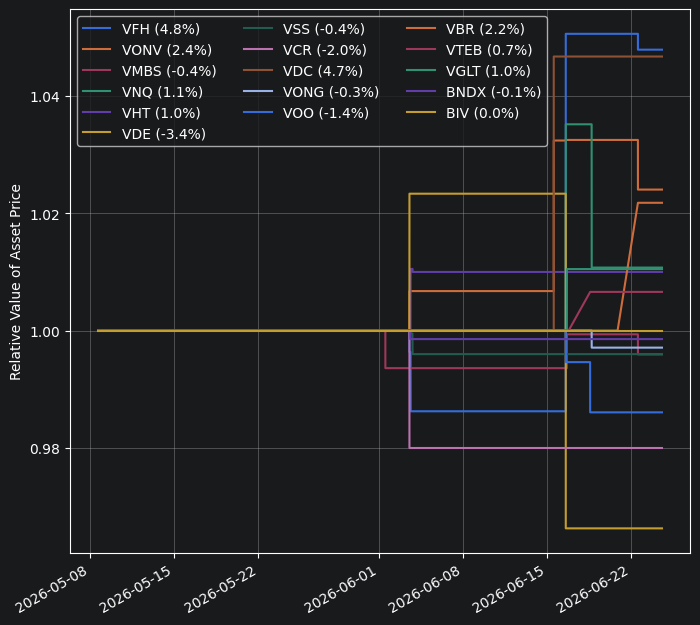

In [54]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [55]:
data_deposits = data[data['trans_type'] == 'Deposits'][['date', 'net_amount', 'account', 'status', 'notes']]
data_deposits

,date,net_amount,account,status,notes
53,2026-06-21 21:31:19+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
55,2026-06-20 12:23:07+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
66,2026-06-18 17:13:20+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
150,2026-06-16 03:43:50+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
152,2026-06-15 21:33:38+00:00,100.0,Visa debit 3333,COMPLETE,Add Cash
...,...,...,...,...,...
583,2026-05-27 00:56:27+00:00,100.0,Visa debit 5895,FAILED,Add Cash
584,2026-05-27 00:56:05+00:00,10.0,Visa debit 5895,COMPLETE,Add Cash
585,2026-05-27 00:43:01+00:00,50.0,Visa debit 5895,COMPLETE,Add Cash
586,2026-05-26 21:58:29+00:00,20.0,Visa debit 5895,COMPLETE,Add Cash


In [56]:
data_deposits['net_amount'].sum()

np.float64(5535.96)

In [57]:
data_deposits['net_amount'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
net_amount,63.0,87.872381,50.715369,1.0,50.0,100.0,100.0,200.0


In [58]:
data_deposits['net_amount'].cumsum()

53      100.00
55      200.00
66      300.00
150     400.00
152     500.00
        ...   
583    5430.96
584    5440.96
585    5490.96
586    5510.96
587    5535.96
Name: net_amount, Length: 63, dtype: float64

In [59]:
(data_deposits
.sort_values('date')
.assign(net_amount=lambda x: x['net_amount'].cumsum())
[['date', 'net_amount']]
)

,date,net_amount
587,2026-05-26 19:39:34+00:00,25.00
586,2026-05-26 21:58:29+00:00,45.00
585,2026-05-27 00:43:01+00:00,95.00
584,2026-05-27 00:56:05+00:00,105.00
583,2026-05-27 00:56:27+00:00,205.00
...,...,...
152,2026-06-15 21:33:38+00:00,5135.96
150,2026-06-16 03:43:50+00:00,5235.96
66,2026-06-18 17:13:20+00:00,5335.96
55,2026-06-20 12:23:07+00:00,5435.96


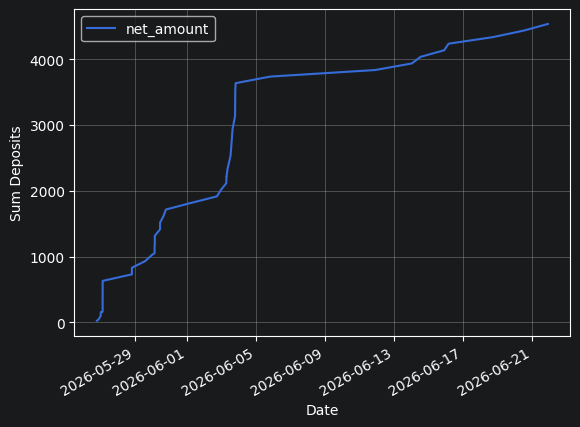

In [60]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .assign(net_amount=lambda x: x['net_amount'].cumsum())
 .plot.line(x='date', y='net_amount')
 )
plt.xlabel('Date')
plt.ylabel('Sum Deposits')
plt.grid()

In [61]:
(data_deposits
 .sort_values('date')
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .pivot_table(index='date', columns='account', values='net_amount', aggfunc='sum', fill_value=0)
 )

account,Visa debit 3333,Visa debit 5895
date,,
2026-05-26 19:39:34+00:00,0.0,25.00
2026-05-26 21:58:29+00:00,0.0,20.00
2026-05-27 00:43:01+00:00,0.0,50.00
2026-05-27 00:56:05+00:00,0.0,10.00
2026-05-27 00:57:28+00:00,0.0,50.00
2026-05-27 03:29:11+00:00,0.0,5.00
2026-05-27 03:29:39+00:00,0.0,10.00
2026-05-27 03:30:06+00:00,0.0,10.00
2026-05-27 03:30:50+00:00,0.0,50.00


In [62]:
(data_deposits
 .pipe(lambda x: x[x['status'] != 'FAILED'])
 .groupby('account')
 ['net_amount']
 .sum()
 )

account
Visa debit 3333    4200.00
Visa debit 5895     335.96
Name: net_amount, dtype: float64